# Data Exploration

Exploring the Crop Recommendation dataset before model training.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset/crop_recommendation_dataset.csv")
print(f"Shape: {df.shape}")

print(f"Columns in our datset: {df.columns}")

print("\n")

print(df.dtypes)

print("\n")

print("Head: ")
print(df.head())
print("\n")

print("Tail: ")
print(df.tail())

print("\n")

print("Checking for null values: ")
print(df.isnull().sum())

print("\n")

print("Statitiscal Summary for Quant variables: ")
print(df.describe())




Shape: (2200, 8)
Columns in our datset: Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


Head: 
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


Tail: 
        N   P   K  temperature   humidity        ph    rainfall   label
2195  107  34  32    26.774637  66.413269  6.780064  177.774507  coffee
2196   99  15  27    27.417112  56.636362  6.086922  127.924610  coffee
2197  118  33  30    24.131797  67.22

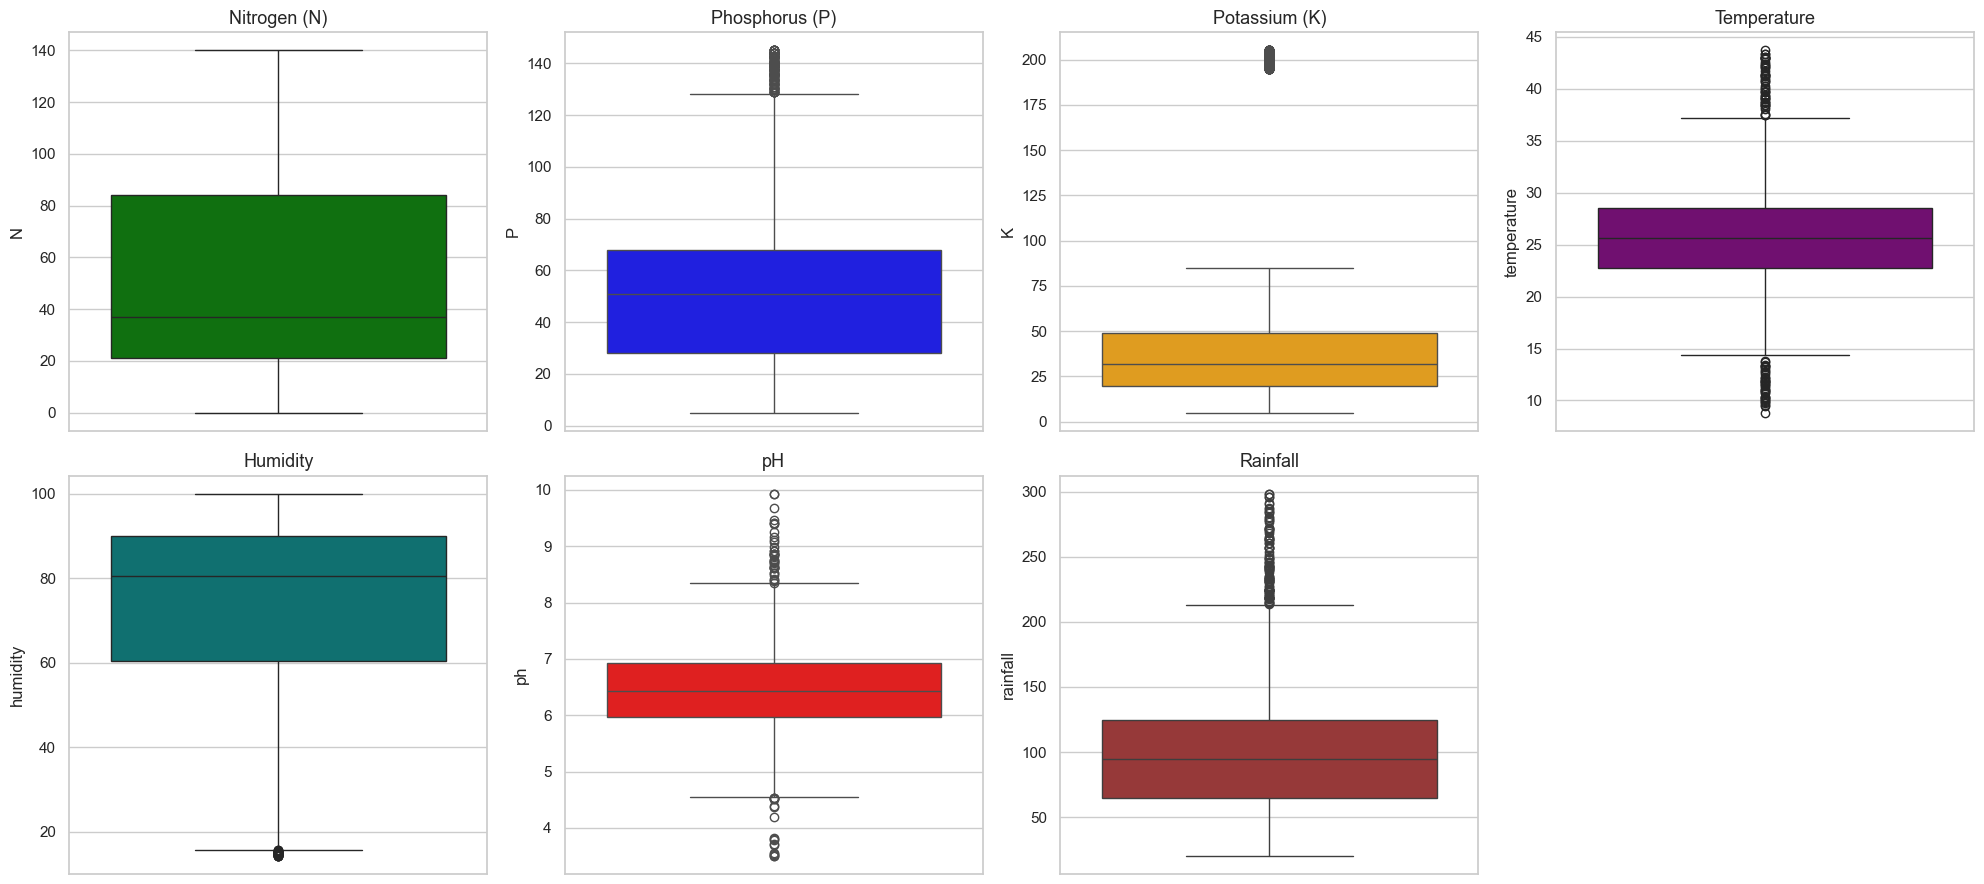

In [24]:
features = ["N", "P", "K", "temperature", "humidity", "ph", "rainfall"]
display_names = ["Nitrogen (N)", "Phosphorus (P)", "Potassium (K)", "Temperature", "Humidity", "pH", "Rainfall"]
colors = ["green", "blue", "orange", "purple", "teal", "red", "brown"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(display_names[i], fontsize=13)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

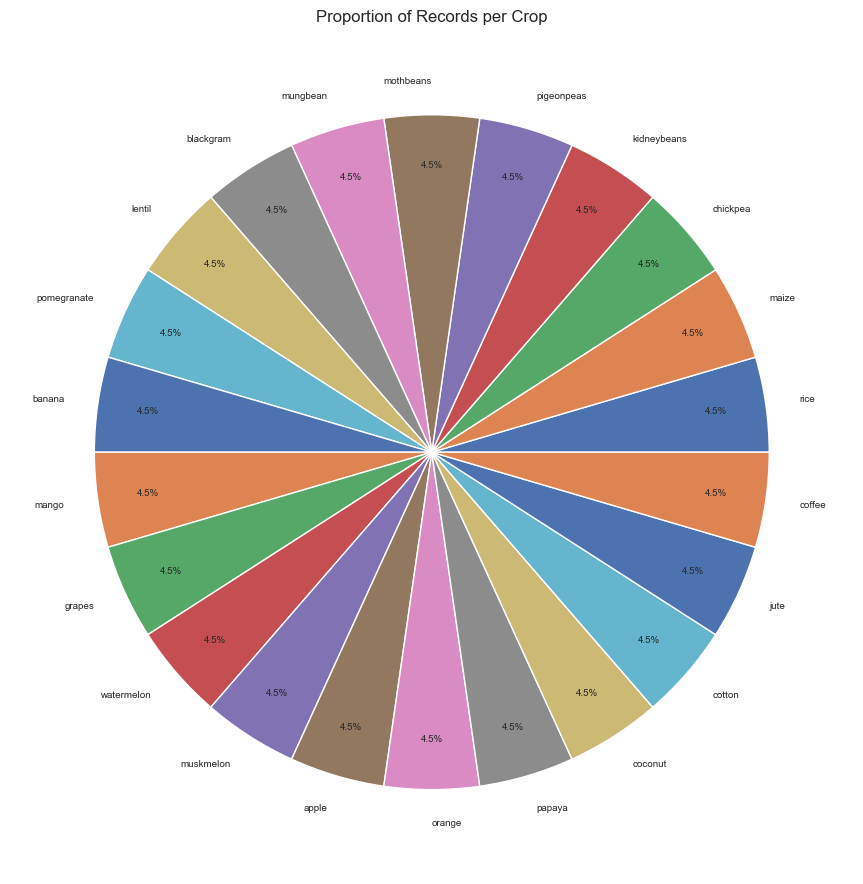

In [27]:
crop_counts = df["label"].value_counts()

plt.figure(figsize=(9, 9))
plt.pie(crop_counts, labels=crop_counts.index, autopct="%1.1f%%", pctdistance=0.85, textprops={"fontsize": 7})
plt.title("Proportion of Records per Crop")
plt.tight_layout()
plt.show()

# Data Exploration and Preprocessing Findings

The dataset has 2,200 rows and 8 columns. Each row is one set of soil and weather
conditions, along with the crop that grows best under those conditions.

Seven of the columns are numeric: N, P, and K (nitrogen, phosphorus, and potassium in
the soil, measured in kg/ha), temperature in °C, humidity in %, ph on a 0 to 14 scale,
and rainfall in mm. 
These are all things a farmer could realistically measure or find
out before planting, which is exactly what the project needs. 
The eighth column, label,is the crop itself. There are 22 different crops in total, so this is a categorical target with 22 classes.

## missing or invalid rows

We found zero missing values and zero duplicate rows across the entire dataset. we also checked that every value made physical sense, like pH staying between 0 and 14, humidity staying between 0 and 100%, and no
negative values for N, P, K, or rainfall. Everything checked out, so we didn't need to
remove or fix any rows.

## boxplots Findings

we plotted a boxplot for each of the 7 numeric features to check for outliers. Every
feature except nitrogen showed points outside the whiskers, which would normally get
flagged as outliers worth removing.

we decided not to remove them. This dataset covers 22 different crops, and each crop has
very different ideal growing conditions, so a value that looks extreme across the whole
dataset can be completely normal for one specific crop. Potassium for example has a
small cluster of values sitting near 200, way above the rest of the data, but that's
just grapes and apple, which genuinely need much more potassium than most other crops.
Removing these would mean deleting real, useful data that the model needs in order to
tell crops apart.

It is not noise, but rather a real  differences between crops, which is a good sign that these features will actually help the model tell them apart.

## pie chart Findings

Every single crop makes up exactly 4.5% of the dataset, 100 records each out of 2,200
total. The dataset is perfectly balanced. This matters because it means we don't need to
do any oversampling or undersampling before training, and accuracy will actually be a
fair metric to judge the models on since no crop is overrepresented.


Overall, the data is clean with no nulls and no duplicates, it's
balanced with equal records per crop, and the unusual values we found in the boxplots and
histograms aren't errors. They're real signals that help separate one crop from another.
The features are also things a real farmer could measure, which keeps the whole system
practical.

